In [1]:
# cell 1 — imports and load color dataset in LAB space
from pathlib import Path
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from scipy.spatial.distance import cdist
import warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = Path('..')
COLOR_ROOT   = PROJECT_ROOT / 'data' / 'raw' / 'color-classification' / 'ColorClassification' / 'ColorClassification'
REPORTS_DIR  = PROJECT_ROOT / 'reports'

COLOR_CLASSES = ['Black', 'Blue', 'Brown', 'Green', 'orange', 'red', 'Violet', 'White', 'yellow']

def extract_lab_stats(img_path: Path) -> dict:
    '''
    Convert image to LAB and compute per-channel statistics.
    LAB is used instead of RGB because:
    - L* = lightness (perceptually uniform)
    - a* = green-red axis
    - b* = blue-yellow axis
    - Distance in LAB space correlates with human perceived color difference
    '''
    img = cv2.imread(str(img_path))
    if img is None:
        return None
    img_lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB).astype(np.float32)
    L, a, b = img_lab[:,:,0], img_lab[:,:,1], img_lab[:,:,2]
    return {
        'L_mean': L.mean(), 'L_std': L.std(),
        'a_mean': a.mean(), 'a_std': a.std(),
        'b_mean': b.mean(), 'b_std': b.std(),
        'L_median': np.median(L),
        'a_median': np.median(a),
        'b_median': np.median(b),
    }

records = []
for cls in COLOR_CLASSES:
    folder = COLOR_ROOT / cls
    if not folder.exists():
        continue
    for img_path in sorted(folder.iterdir()):
        if img_path.suffix.lower() in {'.jpg', '.jpeg', '.png'}:
            stats = extract_lab_stats(img_path)
            if stats:
                stats['class'] = cls.lower()
                stats['path']  = img_path
                records.append(stats)

df_color = pd.DataFrame(records)
print(f'Total images processed : {len(df_color)}')
print(f'Classes                : {df_color["class"].nunique()}')
print()
print(df_color.groupby('class')[['L_mean','a_mean','b_mean']].mean().round(2).to_string())

Total images processed : 117
Classes                : 9

            L_mean      a_mean      b_mean
class                                     
black    47.930000  128.080002  127.570000
blue    135.529999  139.880005   92.669998
brown    82.820000  143.000000  150.990005
green   198.000000  113.040001  137.740005
orange  172.360001  154.710007  162.850006
red     147.500000  161.300003  150.119995
violet  119.449997  144.320007  114.639999
white   232.750000  128.059998  128.550003
yellow  222.320007  129.899994  173.259995


Pairwise ΔE (CIE76) between class centroids:
        black   blue  brown  green  orange    red  violet  white  yellow
black     0.0   95.0   44.6  151.2   132.0  107.4    74.5  184.8   180.3
blue     95.0    0.0   78.7   81.6    80.6   62.5    27.6  104.3   118.9
brown    44.6   78.7    0.0  119.7    91.1   67.2    51.6  152.3   141.9
green   151.2   81.6  119.7    0.0    55.0   70.9    87.7   39.0    46.2
orange  132.0   80.6   91.1   55.0     0.0   28.7    72.3   74.4    56.7
red     107.4   62.5   67.2   70.9    28.7    0.0    48.3   94.0    84.4
violet   74.5   27.6   51.6   87.7    72.3   48.3     0.0  115.3   119.3
white   184.8  104.3  152.3   39.0    74.4   94.0   115.3    0.0    45.9
yellow  180.3  118.9  141.9   46.2    56.7   84.4   119.3   45.9     0.0

Most similar pairs (ΔE < 15):


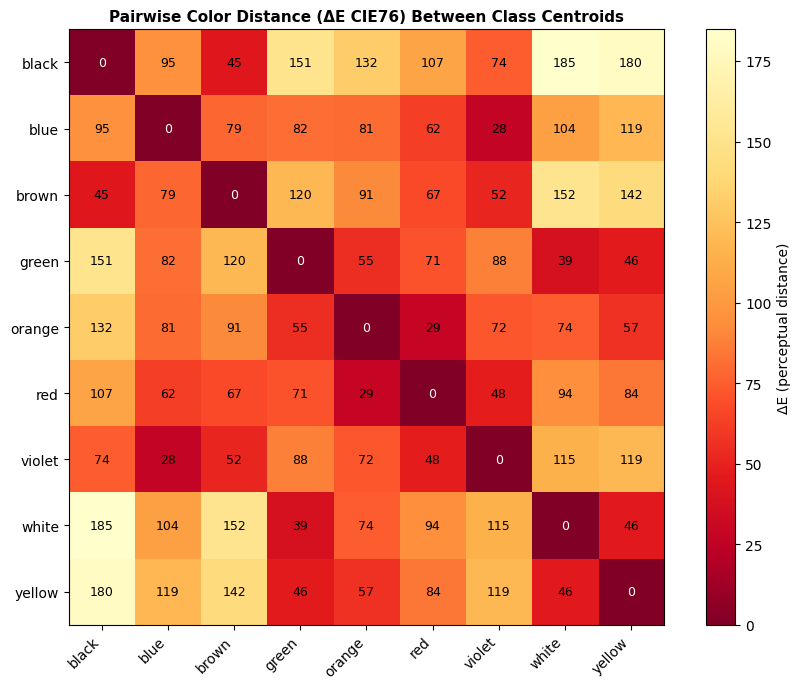

In [2]:
# cell 2 — pairwise Delta-E between class centroids
# Delta-E (CIE76) = Euclidean distance in LAB space
# ΔE < 1  : imperceptible difference
# ΔE 1-2  : perceptible only to trained eye
# ΔE 2-10 : perceptible at a glance
# ΔE > 10 : distinct colors

class_centroids = df_color.groupby('class')[['L_mean','a_mean','b_mean']].mean()
classes = class_centroids.index.tolist()

# Compute ΔE matrix
lab_values = class_centroids.values
delta_e    = cdist(lab_values, lab_values, metric='euclidean')
df_delta_e = pd.DataFrame(delta_e, index=classes, columns=classes)

print('Pairwise ΔE (CIE76) between class centroids:')
print(df_delta_e.round(1).to_string())
print()
print('Most similar pairs (ΔE < 15):')
for i in range(len(classes)):
    for j in range(i+1, len(classes)):
        de = delta_e[i, j]
        if de < 15:
            print(f'  {classes[i]:<12s} ↔ {classes[j]:<12s}  ΔE = {de:.1f}')

# Heatmap
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(delta_e, cmap='YlOrRd_r')
ax.set_xticks(range(len(classes)))
ax.set_yticks(range(len(classes)))
ax.set_xticklabels(classes, rotation=45, ha='right')
ax.set_yticklabels(classes)
for i in range(len(classes)):
    for j in range(len(classes)):
        ax.text(j, i, f'{delta_e[i,j]:.0f}',
                ha='center', va='center', fontsize=9,
                color='white' if delta_e[i,j] < 20 else 'black')
plt.colorbar(im, ax=ax, label='ΔE (perceptual distance)')
ax.set_title('Pairwise Color Distance (ΔE CIE76) Between Class Centroids',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'color_delta_e_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

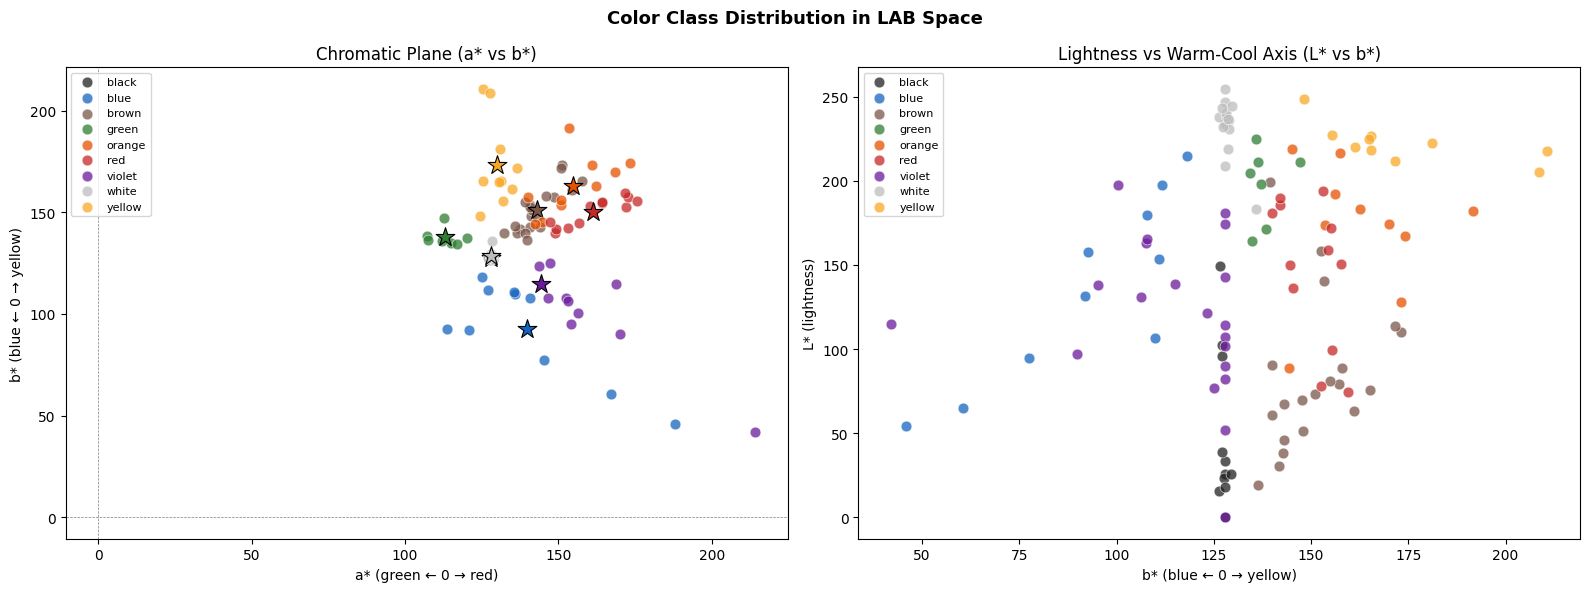

In [3]:
# cell 3 — visualise class clusters in a* b* plane
# a* b* plane shows chromatic content (hue + saturation)
# L* axis (lightness) shown separately via point size

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Color Class Distribution in LAB Space', fontsize=13, fontweight='bold')

# Map class names to approximate display colors for scatter
DISPLAY_COLORS = {
    'black': '#222222', 'blue': '#1565C0', 'brown': '#795548',
    'green': '#2E7D32', 'orange': '#E65100', 'red': '#C62828',
    'violet': '#6A1B9A', 'white': '#BDBDBD', 'yellow': '#F9A825'
}

# Plot 1: a* vs b* (chromatic plane)
for cls, grp in df_color.groupby('class'):
    axes[0].scatter(grp['a_mean'], grp['b_mean'],
                    label=cls, color=DISPLAY_COLORS.get(cls, 'gray'),
                    s=60, alpha=0.75, edgecolors='white', linewidths=0.5)
    # Plot centroid with larger marker
    axes[0].scatter(grp['a_mean'].mean(), grp['b_mean'].mean(),
                    color=DISPLAY_COLORS.get(cls, 'gray'),
                    s=200, marker='*', edgecolors='black', linewidths=0.8)

axes[0].axhline(0, color='gray', lw=0.5, ls='--')
axes[0].axvline(0, color='gray', lw=0.5, ls='--')
axes[0].set_xlabel("a* (green ← 0 → red)", fontsize=10)
axes[0].set_ylabel("b* (blue ← 0 → yellow)", fontsize=10)
axes[0].set_title("Chromatic Plane (a* vs b*)")
axes[0].legend(fontsize=8, loc='upper left')

# Plot 2: L* vs b* (lightness vs warm-cool)
for cls, grp in df_color.groupby('class'):
    axes[1].scatter(grp['b_mean'], grp['L_mean'],
                    label=cls, color=DISPLAY_COLORS.get(cls, 'gray'),
                    s=60, alpha=0.75, edgecolors='white', linewidths=0.5)

axes[1].set_xlabel("b* (blue ← 0 → yellow)", fontsize=10)
axes[1].set_ylabel("L* (lightness)", fontsize=10)
axes[1].set_title("Lightness vs Warm-Cool Axis (L* vs b*)")
axes[1].legend(fontsize=8, loc='upper left')

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'color_lab_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
# cell 4 — how well do raw LAB statistics classify color?
# This is a deliberate baseline: no deep learning, just physics-derived features
# If LAB stats alone achieve high accuracy, it validates that LAB is the right
# representation for color reasoning in coatings

FEATURE_COLS = ['L_mean', 'L_std', 'a_mean', 'a_std',
                'b_mean', 'b_std', 'L_median', 'a_median', 'b_median']

X = df_color[FEATURE_COLS].values
y = LabelEncoder().fit_transform(df_color['class'])

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(max_iter=1000, C=1.0, random_state=42))
])

cv     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(pipeline, X, y, cv=cv, scoring='accuracy')

print('LAB-feature Logistic Regression (5-fold CV):')
print(f'  Per-fold accuracy : {[f"{s:.3f}" for s in scores]}')
print(f'  Mean accuracy     : {scores.mean():.3f} ± {scores.std():.3f}')
print()
print('Interpretation:')
print('  High accuracy here means LAB statistics are a strong')
print('  physics-grounded signal for color identity — validating')
print('  their use in coatings quality control pipelines.')

LAB-feature Logistic Regression (5-fold CV):
  Per-fold accuracy : ['0.750', '0.958', '0.826', '0.826', '0.870']
  Mean accuracy     : 0.846 ± 0.068

Interpretation:
  High accuracy here means LAB statistics are a strong
  physics-grounded signal for color identity — validating
  their use in coatings quality control pipelines.


Mean LAB values per defect class:
                   L_mean      a_mean      b_mean
label                                            
adhesion_loss   98.540001  149.059998  132.039993
blistering     166.800003  127.209999  127.080002
chalking       175.740005  124.589996  128.639999
corrosion      129.649994  131.740005  133.369995
crack_paint    170.919998  115.160004  121.309998
fading         139.880005  123.790001  115.730003
sagging        164.460007  124.650002  116.910004



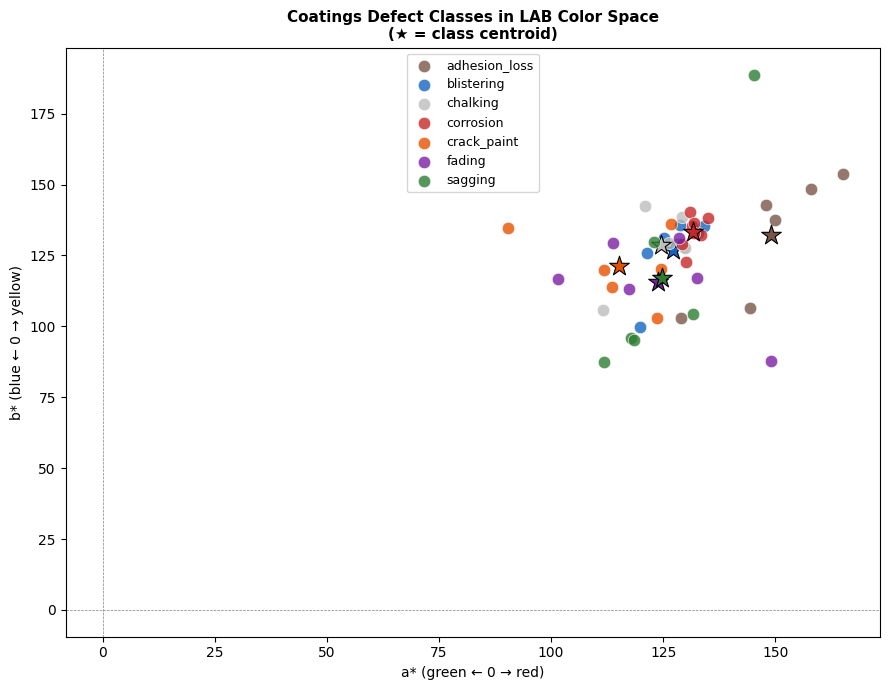

In [5]:
# cell 5 — do coatings defect classes separate in LAB space?
# This connects color analysis back to the main coatings project

MANIFEST_PATH = PROJECT_ROOT / 'data' / 'coatings_manifest.csv'
df_coatings   = pd.read_csv(MANIFEST_PATH)
df_coatings['abs_path'] = df_coatings['path'].apply(
    lambda p: PROJECT_ROOT.resolve() / p)

defect_records = []
for _, row in df_coatings.iterrows():
    stats = extract_lab_stats(row['abs_path'])
    if stats:
        stats['label'] = row['label']
        defect_records.append(stats)

df_defect_lab = pd.DataFrame(defect_records)

print('Mean LAB values per defect class:')
print(df_defect_lab.groupby('label')[['L_mean','a_mean','b_mean']].mean().round(2).to_string())
print()

# Scatter: defect classes in a* b* plane
DEFECT_COLORS = {
    'adhesion_loss': '#795548', 'blistering':  '#1565C0',
    'chalking':      '#BDBDBD', 'corrosion':   '#C62828',
    'crack_paint':   '#E65100', 'fading':      '#7B1FA2',
    'sagging':       '#2E7D32',
}

fig, ax = plt.subplots(figsize=(9, 7))
for lbl, grp in df_defect_lab.groupby('label'):
    ax.scatter(grp['a_mean'], grp['b_mean'],
               label=lbl, color=DEFECT_COLORS.get(lbl, 'gray'),
               s=80, alpha=0.8, edgecolors='white', linewidths=0.5)
    ax.scatter(grp['a_mean'].mean(), grp['b_mean'].mean(),
               color=DEFECT_COLORS.get(lbl, 'gray'),
               s=220, marker='*', edgecolors='black', linewidths=0.8)

ax.axhline(0, color='gray', lw=0.5, ls='--')
ax.axvline(0, color='gray', lw=0.5, ls='--')
ax.set_xlabel("a* (green ← 0 → red)", fontsize=10)
ax.set_ylabel("b* (blue ← 0 → yellow)", fontsize=10)
ax.set_title('Coatings Defect Classes in LAB Color Space\n(★ = class centroid)',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'defect_lab_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

Pairwise ΔE between defect class centroids:
               adhesion_loss  blistering  chalking  corrosion  crack_paint  fading  sagging
adhesion_loss            0.0        71.8      81.1       35.6         80.6    51.1     71.9
blistering              71.8         0.0       9.4       37.9         14.0    29.4     10.7
chalking                81.1         9.4       0.0       46.9         12.9    38.1     16.3
corrosion               35.6        37.9      46.9        0.0         46.1    21.9     39.2
crack_paint             80.6        14.0      12.9       46.1          0.0    32.7     12.3
fading                  51.1        29.4      38.1       21.9         32.7     0.0     24.6
sagging                 71.9        10.7      16.3       39.2         12.3    24.6      0.0

Perceptual interpretation:
  ΔE < 10  → visually indistinguishable in color → texture is the only discriminator
  ΔE 10-30 → subtle color difference → both color and texture matter
  ΔE > 30  → clearly distinct color  →

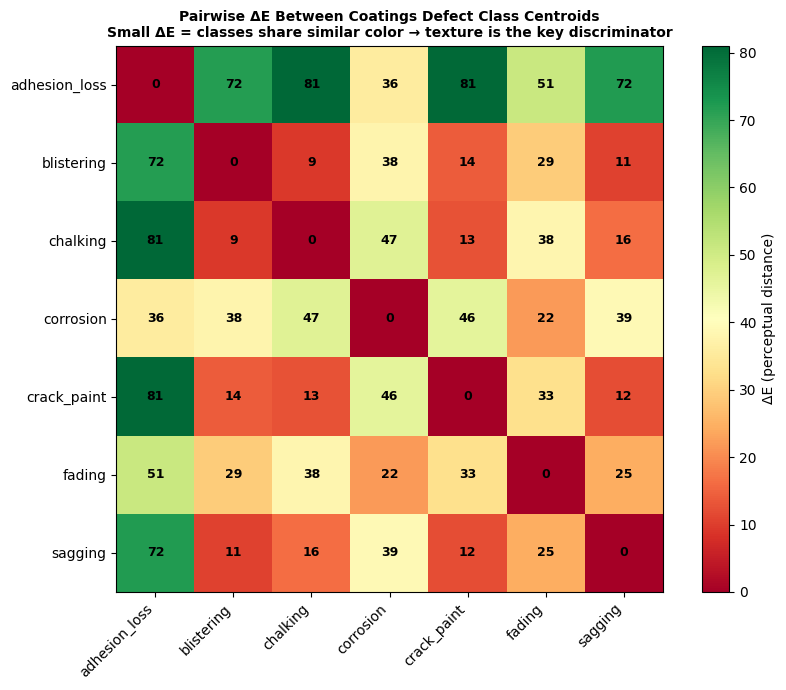

In [6]:
# cell 6 — pairwise Delta-E between defect class centroids
# This quantifies WHY texture-based deep learning is necessary:
# if defect classes were far apart in LAB space, color alone would suffice.
# Small ΔE between defects proves that texture (CNN) is the differentiating signal.

defect_centroids = df_defect_lab.groupby('label')[['L_mean','a_mean','b_mean']].mean()
defect_classes   = defect_centroids.index.tolist()
defect_lab_vals  = defect_centroids.values

defect_delta_e   = cdist(defect_lab_vals, defect_lab_vals, metric='euclidean')
df_defect_de     = pd.DataFrame(defect_delta_e, index=defect_classes, columns=defect_classes)

print('Pairwise ΔE between defect class centroids:')
print(df_defect_de.round(1).to_string())
print()
print('Perceptual interpretation:')
print('  ΔE < 10  → visually indistinguishable in color → texture is the only discriminator')
print('  ΔE 10-30 → subtle color difference → both color and texture matter')
print('  ΔE > 30  → clearly distinct color  → color alone is informative')
print()

# Find the most and least separable pairs
pairs = []
for i in range(len(defect_classes)):
    for j in range(i+1, len(defect_classes)):
        pairs.append((defect_classes[i], defect_classes[j], defect_delta_e[i,j]))
pairs.sort(key=lambda x: x[2])

print('Most similar defect pairs (hardest for color to separate):')
for a, b, de in pairs[:4]:
    print(f'  {a:<15s} ↔ {b:<15s}  ΔE = {de:.1f}')

print()
print('Most distinct defect pairs (color helps here):')
for a, b, de in pairs[-3:]:
    print(f'  {a:<15s} ↔ {b:<15s}  ΔE = {de:.1f}')

# Heatmap
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(defect_delta_e, cmap='RdYlGn')
ax.set_xticks(range(len(defect_classes)))
ax.set_yticks(range(len(defect_classes)))
ax.set_xticklabels(defect_classes, rotation=45, ha='right')
ax.set_yticklabels(defect_classes)
for i in range(len(defect_classes)):
    for j in range(len(defect_classes)):
        ax.text(j, i, f'{defect_delta_e[i,j]:.0f}',
                ha='center', va='center', fontsize=9, fontweight='bold',
                color='black')
plt.colorbar(im, ax=ax, label='ΔE (perceptual distance)')
ax.set_title('Pairwise ΔE Between Coatings Defect Class Centroids\n'
             'Small ΔE = classes share similar color → texture is the key discriminator',
             fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'defect_delta_e_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# cell 7 — can LAB features alone classify coatings defects?
# Contrast with color dataset (84.6%) to make the argument:
# defects require texture-aware models because color is insufficient

DEFECT_FEATURE_COLS = ['L_mean', 'L_std', 'a_mean', 'a_std',
                       'b_mean', 'b_std', 'L_median', 'a_median', 'b_median']

X_def = df_defect_lab[DEFECT_FEATURE_COLS].values
y_def = LabelEncoder().fit_transform(df_defect_lab['label'])

pipeline_def = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(max_iter=1000, C=1.0, random_state=42))
])

cv_def     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_def = cross_val_score(pipeline_def, X_def, y_def, cv=cv_def, scoring='accuracy')

print('LAB-feature classifier on COATINGS DEFECTS (5-fold CV):')
print(f'  Per-fold accuracy : {[f"{s:.3f}" for s in scores_def]}')
print(f'  Mean accuracy     : {scores_def.mean():.3f} ± {scores_def.std():.3f}')
print()
print('Comparison summary:')
print(f'  LAB stats on color classes  : 84.6%  (color is separable in LAB)')
print(f'  LAB stats on defect classes : {scores_def.mean()*100:.1f}%  (defects are NOT separable by color)')
print(f'  EfficientNet on defects     : 88.9%  (texture features are the key signal)')
print()
print('Conclusion: LAB color features are necessary but not sufficient for')
print('defect classification. Deep texture features from CNN are required.')
print('This justifies the full pipeline: LAB analysis + CNN classifier together.')

LAB-feature classifier on COATINGS DEFECTS (5-fold CV):
  Per-fold accuracy : ['0.444', '0.444', '0.333', '0.222', '0.444']
  Mean accuracy     : 0.378 ± 0.089

Comparison summary:
  LAB stats on color classes  : 84.6%  (color is separable in LAB)
  LAB stats on defect classes : 37.8%  (defects are NOT separable by color)
  EfficientNet on defects     : 88.9%  (texture features are the key signal)

Conclusion: LAB color features are necessary but not sufficient for
defect classification. Deep texture features from CNN are required.
This justifies the full pipeline: LAB analysis + CNN classifier together.
